<a href="https://colab.research.google.com/github/Toiati-salah-eddine-001/Deep_Learning_G/blob/main/pre-train_model_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
# Configuration des constantes
IMG_SIZE=(224,224)
BATCH_SEZE=32
EPOCHS=5
AUTOTUNE=tf.data.AUTOTUNE #Optimisation automatique des performances

#1-Chargement du Dataset
## see the documentatoin:
https://www.tensorflow.org/tutorials/load_data/images


In [ ]:
(train_ds, val_ds, test_ds), metadata=tfds.load(
    name="tf_flowers" ,
    split=['train[:70%]', 'train[70%:85%]','train[85%:]'],
    as_supervised=True,
    with_info=True
)
num_classes = metadata.features['label'].num_classes
class_names = metadata.features["label"].names
print(num_classes)
print(class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.4L7ZI2_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
5
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


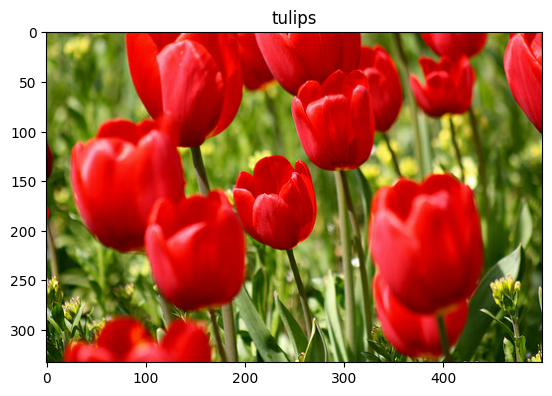

In [ ]:
get_label_name = metadata.features['label'].int2str

image, label = next(iter(train_ds))
_ = plt.imshow(image)
_ = plt.title(get_label_name(label))

## Prétraitement et Data Augmentation

## Ressource:
https://www.tensorflow.org/tutorials/images/data_augmentation

In [ ]:
# Redimensionnement
def resize_image(image,label):
  image = tf.image.resize(image,IMG_SIZE)
  return tf.cast(image,tf.float32),label

# Augmentation (uniquement pour l'entraînement)
data_augmentatio=keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Pipeline de données optimisé
def preapre_ds(ds,augment=False) :
  ds=ds.map(resize_image,num_parallel_calls=AUTOTUNE)
  if augment:
    ds=ds.map(lambda x,y:(data_augmentatio(x,training=True),y), num_parallel_calls=AUTOTUNE)

  # Prétraitement spécifique à MobileNetV2 (mise à l'échelle des pixels entre -1 et 1)
  ds = ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))
  return ds.batch(BATCH_SEZE).prefetch(AUTOTUNE)

train_ds = preapre_ds(train_ds, augment=True)
val_ds = preapre_ds(val_ds)
test_ds = preapre_ds(test_ds)


### Construction du Modèle (Transfer Learning)

In [ ]:
# Chargement du modèle de base sans la couche de classification finale
model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet",
)

model.summary()


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
# On gèle les poids du modèle de base
model.trainable=False

In [ ]:
# Construction du modèle final
my_model=keras.Sequential([
    model,
    layers.GlobalAveragePooling2D(),
    # layers.Dense(120,activation='relu')
    # layers.dropout(0.1)
    # layers.Dense(120,activation='relu')
    layers.Dropout(0.1),
    layers.Dense(num_classes,activation="softmax")
])

### What is Sparse Categorical Crossentropy:
https://www.geeksforgeeks.org/machine-learning/what-is-sparse-categorical-crossentropy/

In [ ]:
my_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
my_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### traînement:

### fit information :
https://www.geeksforgeeks.org/deep-learning/model-fit-in-tensorflow/

In [ ]:
history=my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.6676 - loss: 0.8650 - val_accuracy: 0.8149 - val_loss: 0.5160
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8365 - loss: 0.4608 - val_accuracy: 0.8621 - val_loss: 0.4064
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.8692 - loss: 0.3761 - val_accuracy: 0.8748 - val_loss: 0.3701
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8836 - loss: 0.3379 - val_accuracy: 0.8766 - val_loss: 0.3456
Epoch 5/5
76/81 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9041 - loss: 0.2936 

# Évaluation sur le jeu de test

In [ ]:
loss, accuracy = my_model.evaluate(test_ds)
print(f"Precision sur le test :{accuracy*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8982 - loss: 0.2897
Precision sur le test :89.82%


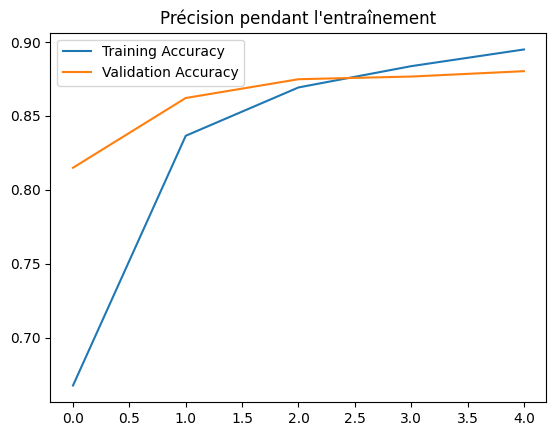

In [ ]:
# Visualisation des courbes
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Précision pendant l\'entraînement')
    plt.show()

plot_history(history)